# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import glob
import graphical_sampling as gs
import pandas as pd
import numpy as np
import itertools
from tqdm import tqdm
from package_sampling.utils import inclusion_probabilities

/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "LD_LIBRARY_PATH" redefined by R and overriding existing variable. Current: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server", R: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server"
  warnings.warn(
/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_LIBS_SITE" redefined by R and overriding existing variable. Current: "/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library:/usr/lib/R/site-library:/usr/lib/R/library", R: "/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library:/usr/lib/R/site-library:/usr/lib/R/library:/usr/lib/R/library:/usr/lib/R/

# Loading and Determining Population

In [3]:
DATA_DIR = "populations"
csv_paths = glob.glob(os.path.join(DATA_DIR, "*.csv"))

coords_dict = {}
probs_dict = {}

for fp in csv_paths:
    name = os.path.splitext(os.path.basename(fp))[0]
    data = np.loadtxt(fp, delimiter=",", skiprows=1)
    coords = data[:, :2]
    probs  = data[:, -1]

    coord_name, prob_name, *rest = name.split("_")
    coord_name = 'cluster' if coord_name == 'clust' else coord_name
    prob_name = 'equal' if prob_name == 'eq' else 'unequal'

    coords_dict[coord_name] = coords
    probs_dict[coord_name] = probs_dict.get(coord_name, {})
    probs_dict[coord_name][prob_name] = probs

print(coords_dict.keys())
print(probs_dict.keys())
print(probs_dict['random'].keys())

dict_keys(['cluster', 'AggregatedPop1027', 'random', 'meuse', 'grid', 'RegularPop1000', 'swiss'])
dict_keys(['cluster', 'AggregatedPop1027', 'random', 'meuse', 'grid', 'RegularPop1000', 'swiss'])
dict_keys(['equal', 'unequal'])


In [226]:
n = 16
coords = coords_dict['grid']
probs = probs_dict['grid']['equal']
print(n)
modified_probs = inclusion_probabilities(probs, n=n)
pop = gs.Population(coords, modified_probs)

16


# Building Initial Designs

In [227]:
orders = [
    # "lexico-yx",
    # "lexico-xy",
    # "random",
    # "angle_0",
    # "distance_0",
    # "projection",
    # "center",
    "spiral",
    # "max",
    # "snake",
    # "hilbert",
]
n_zones_sweep = [(1, 1)]
# n_zones_cluster = [4]
combinations = list(itertools.product(['sweep'], n_zones_sweep, orders, orders))# + list(itertools.product(['cluster'], n_zones_cluster, orders, orders))

In [228]:
initial_designs = []
num_trials = 1
for zone_builder, n_zones, units_order, zones_order in tqdm(combinations, desc="Generating initial designs", total=len(combinations), unit="orders"):
    best = None
    best_score = np.inf
    for _ in range(num_trials):
        ks = gs.sampling.KMeansSampler(
            population=pop,
            n=n,#(5,3,2),#(25,2),#50,#,2,2,2),
            cluster_in_cluster=False,
            n_clusters=n,
            n_zones=n_zones,
            zone_builder=zone_builder,
            units_order=units_order,
            zones_order=zones_order,
            split_size=0.001
        )
        if ks.expected_moran_score() < best_score:
            best = ks
            best_score = ks.expected_moran_score()
            print(f"New best score: {best_score} for {zone_builder}, {n_zones}, {units_order}, {zones_order}")

    initial_designs.append(gs.NewDesign(best))

Generating initial designs: 100%|██████████| 1/1 [00:05<00:00,  5.94s/orders]

New best score: -0.5021912587451169 for sweep, (1, 1), spiral, spiral


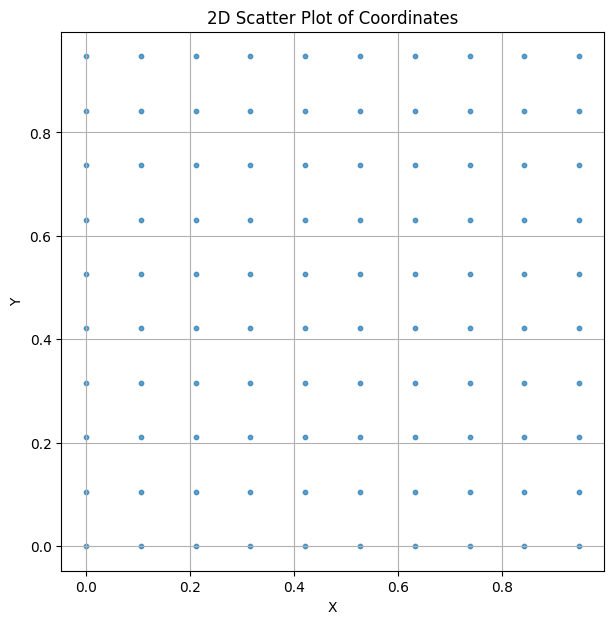

In [229]:
import matplotlib.pyplot as plt

# coords already loaded from your code above

plt.figure(figsize=(7, 7))
plt.scatter(coords[:, 0], coords[:, 1], s=10, alpha=0.7)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("2D Scatter Plot of Coordinates")
plt.grid(True)
plt.show()

# Run

In [230]:
moran_criteria = gs.criteria.MoranCriteria()

In [231]:
initial_criteria_value = np.array([moran_criteria(design) for design in initial_designs])
print(initial_criteria_value)
best_design = initial_designs[np.argmin(initial_criteria_value)]
best_criteria_value = np.min(initial_criteria_value)
best_criteria_value
print(initial_designs[np.argmin(initial_criteria_value)].kmeans.score_summary_df())


[-0.50219126]
               expected       std
measure                          
density        0.089074  0.076553
moran         -0.502191  0.086772
local_balance  0.159049  0.019686
voronoi        0.101525  0.028666


In [232]:
astar = gs.search.AStar(
    initial_designs,
    moran_criteria
)

best initial criteria value -0.5021912587451169


In [156]:
astar = gs.search.AStar(
    [astar.best_design],
    moran_criteria
)

best initial criteria value -0.3126920765378461


In [233]:
astar.run(
    max_iterations = 200,
    num_new_nodes = 20,
    max_open_set_size = 1000,

    n_clusters_to_change_order_zone = 1,
    n_changes_in_order_of_zones = 1,

    n_clusters_to_change_order_units = 1,
    n_zones_to_change_order_units = 1,
    n_changes_in_order_of_units = 1,

    n_jobs=-1
)


parent node: -0.5021912587451169
child node: -0.4980602623066769
child node: -0.5088169881357536

New best criteria value: -0.5088169881357536
child node: -0.5077754583114027
child node: -0.5001671070891155
child node: -0.5049377015154348
child node: -0.4961387930768679
child node: -0.47522844988592505
child node: -0.5069309352027616
child node: -0.4608500360744411
child node: -0.48573596141021713
child node: -0.4931188325697488
child node: -0.4936324175416801
child node: -0.5023396020798713
child node: -0.489074463796518
child node: -0.47265514783121676
child node: -0.4981421110230344
child node: -0.4703422908255181

parent node: -0.5088169881357536
child node: -0.5009752550917139
child node: -0.5114319710809829

New best criteria value: -0.5114319710809829
child node: -0.5047678404136711
child node: -0.5002864387075263
child node: -0.4938131045176196
child node: -0.485425024926126
child node: -0.49171705833700763
child node: -0.4848969501439842
child node: -0.4966086695076309
child 

200

In [225]:
print(astar.best_design.kmeans.score_summary_df())
print(astar.best_design.kmeans.all_samples_probs.sum())
print(round(np.mean(np.abs(astar.best_design.kmeans.fips - modified_probs)), 4))

               expected       std
measure                          
density        0.202905  0.127784
moran         -0.550326  0.071871
local_balance  0.197885  0.051410
voronoi        0.067200  0.034341
1.0000000000000002
0.0


In [31]:
astar.best_design.kmeans.fips

array([0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08,
       0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08,
       0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08,
       0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08,
       0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08,
       0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08,
       0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08,
       0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08,
       0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08,
       0.08])

In [32]:
astar.best_design.kmeans.all_samples_probs.sum()

np.float64(1.0)

In [33]:
astar.best_design.kmeans.all_samples.shape

(47, 8)

In [36]:
np.mean(np.abs(astar.best_design.kmeans.fips - modified_probs))

np.float64(1.6237011735142913e-17)

In [35]:
probs

array([0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01])

In [29]:
type(astar.best_design)
dir(astar.best_design)
vars(astar.best_design)
vars(astar.best_design.kmeans)



{'population': <graphical_sampling.population.Population at 0x7944210c79c0>,
 'coords': array([[0.88581688, 1.        ],
        [0.86894075, 0.98639979],
        [0.91921005, 0.98101103],
        [0.96696589, 0.96741083],
        [0.97019749, 0.92789325],
        [1.        , 0.90993072],
        [0.91921005, 0.93815756],
        [0.86965889, 0.9363613 ],
        [0.88150808, 0.90248909],
        [0.9432675 , 0.88632281],
        [0.92854578, 0.87272261],
        [0.87145422, 0.85116756],
        [0.81472172, 0.93020272],
        [0.84883303, 0.90787785],
        [0.86391382, 0.88452656],
        [0.7989228 , 0.90633821],
        [0.77486535, 0.86989992],
        [0.75008977, 0.83602771],
        [0.72531418, 0.80395176],
        [0.70017953, 0.76802669],
        [0.73141831, 0.76828329],
        [0.75368043, 0.77059276],
        [0.75368043, 0.75699256],
        [0.91490126, 0.82396715],
        [0.91274686, 0.79779317],
        [0.91992819, 0.78624583],
        [0.86283662, 0.785989

In [31]:
list(astar.best_design.iterate(10)) 


TypeError: 'NoneType' object is not iterable

In [53]:
astar.best_design.kmeans.all_samples_probs.sum()
print(astar.best_design.kmeans.all_samples[0])
print(astar.best_design.kmeans.all_samples_probs[0])


[130   2 132   5 135 137  11 139  13 143 144 146  20  21 151 152 153 154
  24  27  29  32  34  36  41  44  47  49  58  66  69  71  72  83  88  94
  97 101 105 107 109 110 112 114 115 119 121 122 124 125]
0.409168081


In [59]:
astar.best_design.kmeans.fips.sum()

np.float64(48.981324300000004)

In [34]:
np.mean(np.abs(initial_design.kmeans.fips - probs))

NameError: name 'initial_design' is not defined

In [33]:
max(astar.best_design.kmeans.fips)

np.float64(0.5939474570000002)

In [88]:
200/1027

0.19474196689386564

In [29]:
np.sqrt(astar.best_design.kmeans.var_moran_score())

np.float64(0.051920976433342605)

In [32]:
astar.best_design.kmeans.moran_scores

array([-0.43553833, -0.55288235, -0.45847026, -0.47613364, -0.35700185,
       -0.46503158, -0.45420885, -0.45498503, -0.48866027, -0.48846099,
       -0.49167114, -0.49182751, -0.4739987 , -0.49749307, -0.47729261,
       -0.41997761, -0.41852084, -0.40981854, -0.49555827, -0.54490175,
       -0.51248604, -0.44614431, -0.51264911, -0.4566424 , -0.45323804,
       -0.46697799, -0.43691147, -0.48270515, -0.45059183, -0.42996386,
       -0.4815179 , -0.44129174, -0.40494318, -0.46570155, -0.43632086,
       -0.51402903, -0.53989802, -0.51496589, -0.39044831, -0.40970401])

In [67]:
astar.best_design.kmeans.score_summary_df()

,expected,std
measure,,
density,0.166571,0.117680
moran,-0.452472,0.068235
local_balance,0.226800,0.052961
voronoi,0.090396,0.046718


NameError: name 'initial_design' is not defined

In [30]:
def info(kmeans):
    mean = round(float(kmeans.expected_moran_score()), 2)
    moran_scores = astar.best_design.kmeans.moran_scores
    median = round(float(np.median(moran_scores)), 2)
    sd = round(float(np.sqrt(kmeans.var_moran_score())), 2)
    min_ = round(float(np.min(moran_scores)), 2)
    max_ = round(float(np.max(moran_scores)), 2)
    return mean, median, sd, min_, max_

In [31]:
info(astar.best_design.kmeans)

(-0.25, -0.25, 0.05, -0.4, -0.14)

In [23]:
gs.plot(pop, astar.best_design.kmeans.clusters, connect_points=False)

NameError: name 'astar' is not defined